##### Author: Jimin Kim (jk55@uw.edu)
##### Version 1.9.0

# Lab 4 Report

## Group Members: Jeremy Thomas, Jakob Tak
## Group Name for Leaderboard: Team 29

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st

In [2]:
from IPython.display import Image as ipyimage #For displaying images in colab jupyter cell

### Exercise 1: Construct Dictionaries from Data

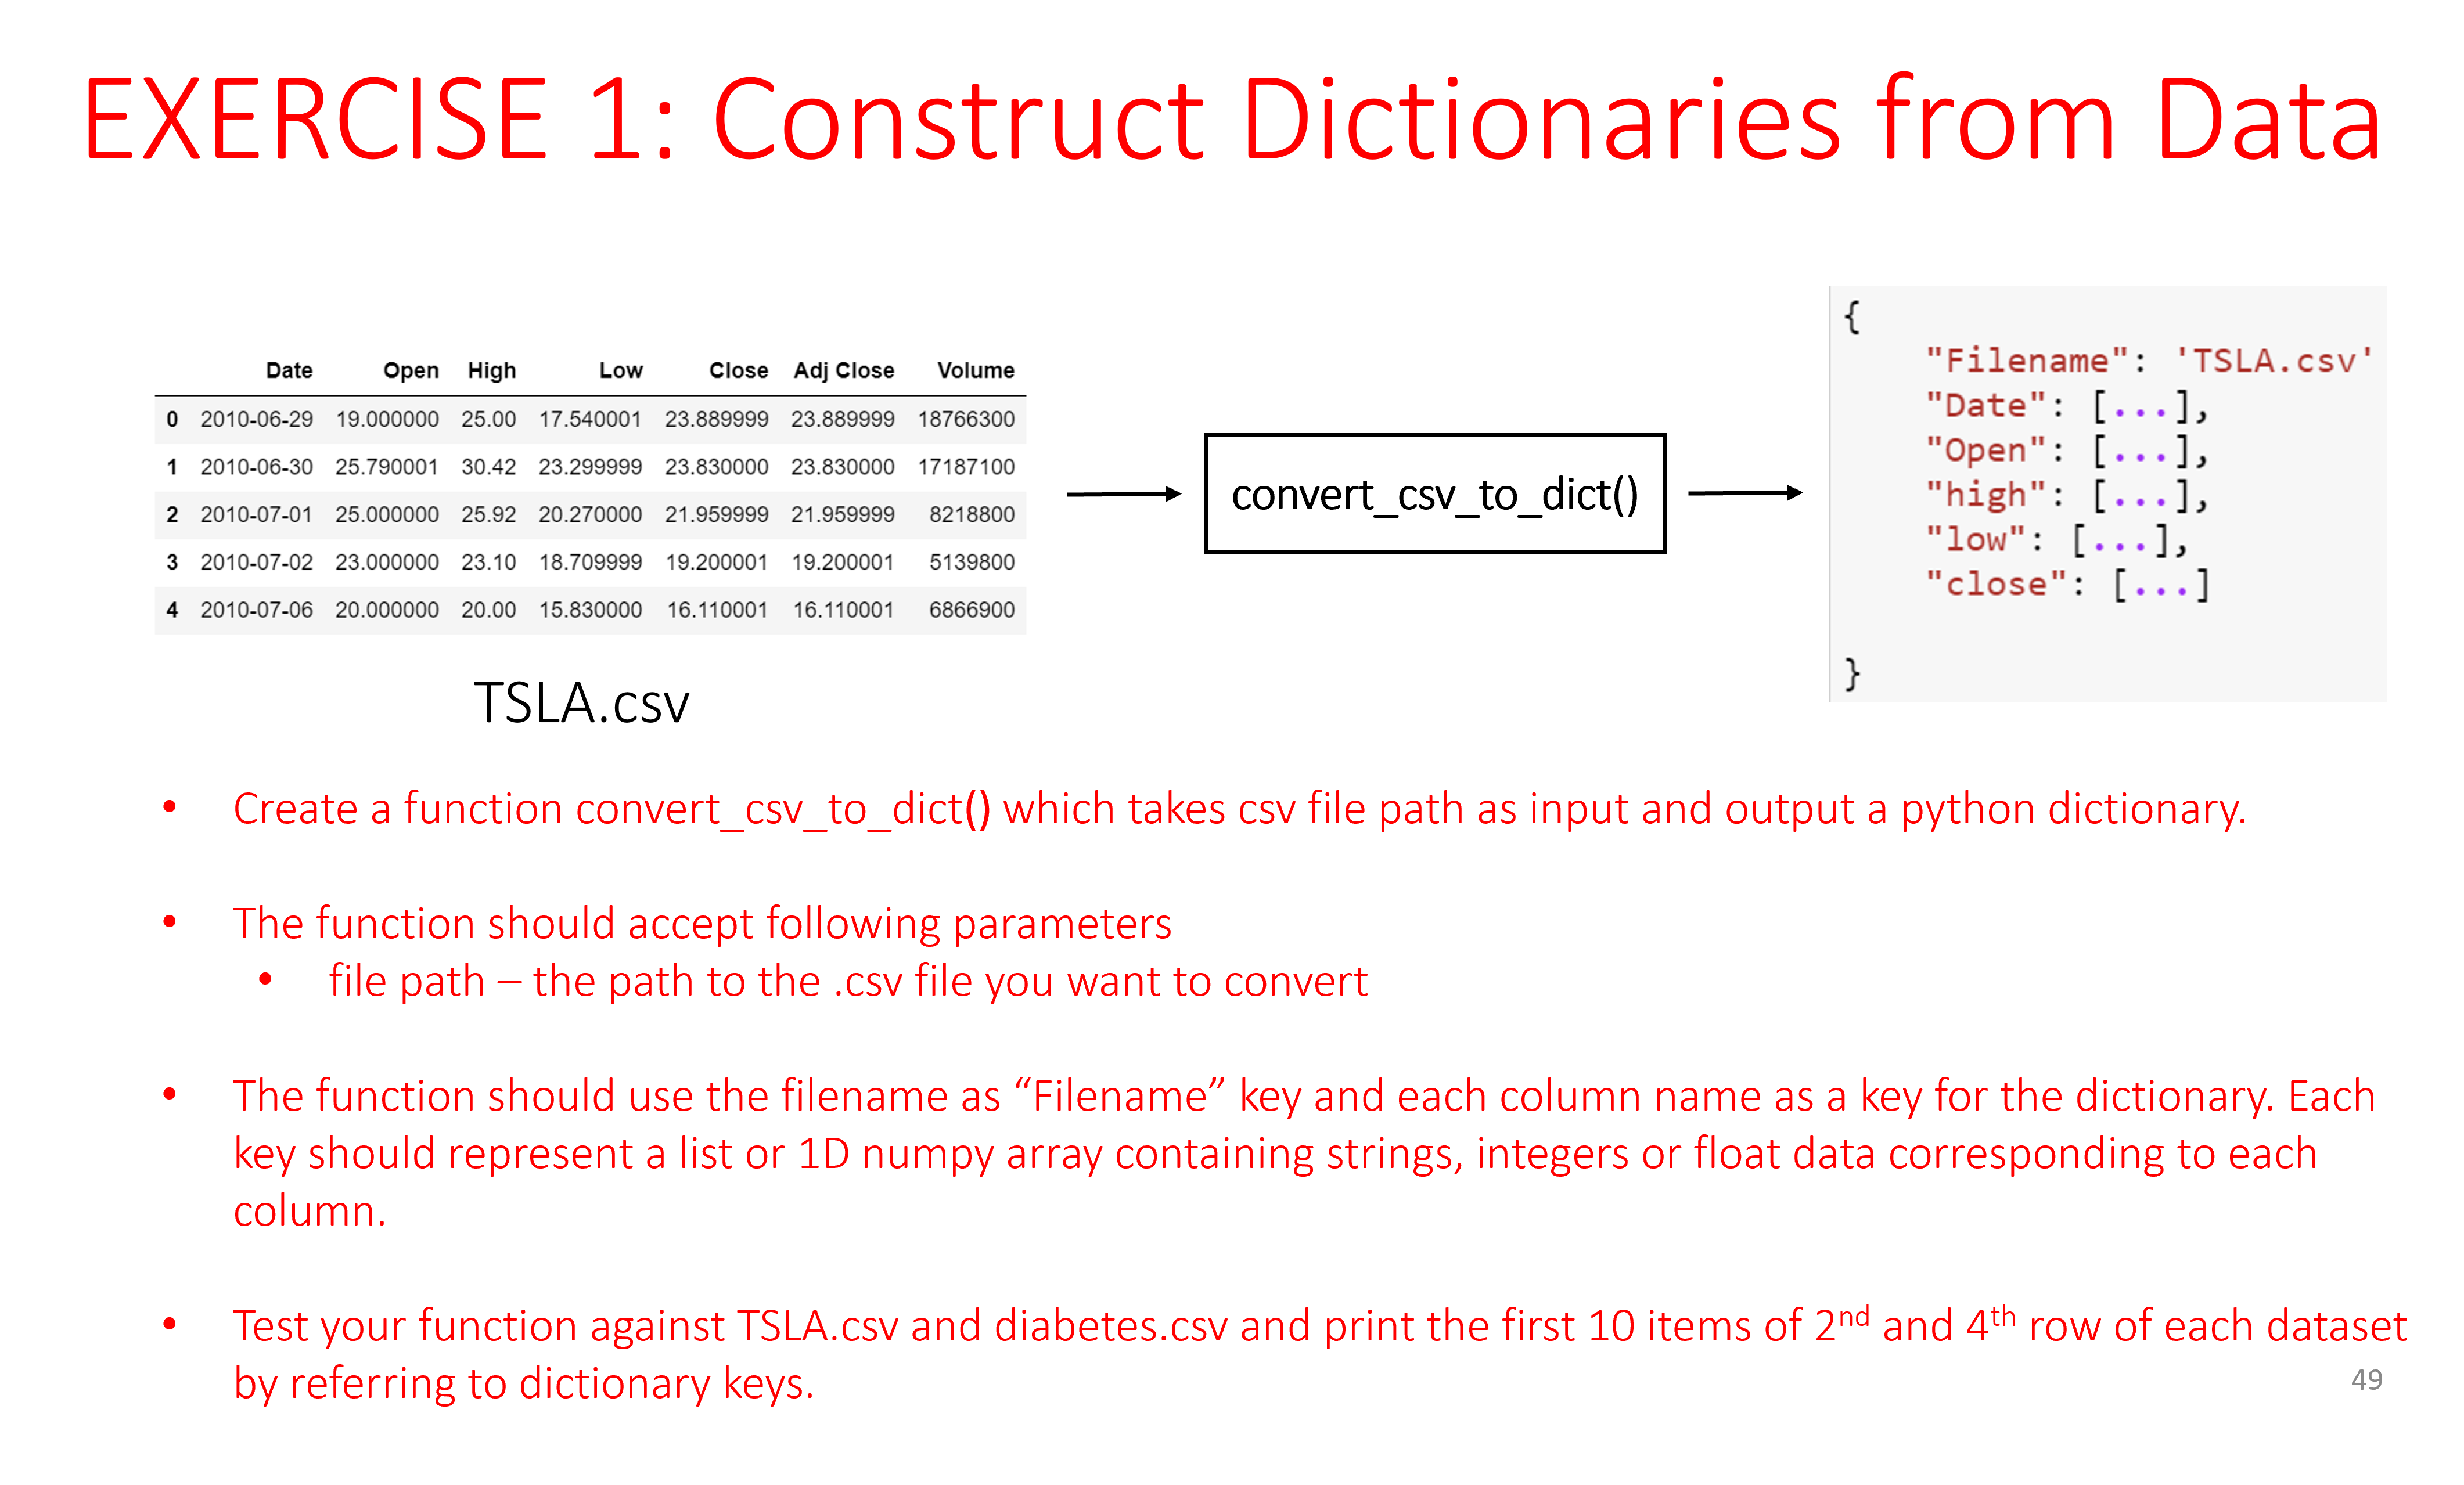

In [3]:
ipyimage('lab4_exercise1.PNG', width = 1000)

In [4]:
def convert_csv_to_dict(file_path):
    """
    Converts a CSV file to a dictionary with filename and column data.
    Args:
        file_path (str): The path to the CSV file.
    Returns:
        dict: A dictionary containing the filename and column data.
    """

    # Read the CSV file using pandas    
    data = pd.read_csv(file_path)

    # Convert the DataFrame to a NumPy array
    data_array = data.to_numpy()

    # Create a key-value pair for the filename
    data_filename = {'Filename': file_path}

    # Create key-value pairs for each column in the CSV using a dictionary comprehension
    data_columns = {col_name: data_array[:, col].tolist() for col, col_name in enumerate(data.columns)}

    # Combine the filename dictionary and the column data dictionary into a single dictionary
    dict_object = {**data_filename, **data_columns}
    
    return dict_object

In [5]:
TSLA_dict = convert_csv_to_dict('TSLA.csv')

In [6]:
# Navigate to keys corresponding to 2nd and 4th columns (Open and Low prices) of TSLA.csv, 
# Print first 10 elements of each key.
TSLA_column2 = "Open"
TSLA_column4 = "Low"
print(TSLA_dict[TSLA_column2][:10])
print(TSLA_dict[TSLA_column4][:10])

[19.0, 25.790001, 25.0, 23.0, 20.0, 16.4, 16.139999, 17.58, 17.950001, 17.389999]
[17.540001, 23.299999, 20.27, 18.709999, 15.83, 14.98, 15.57, 16.549999, 17.0, 16.9]


In [7]:
diabetes_dict = convert_csv_to_dict('diabetes.csv')

In [8]:
# Navigate to keys corresponding to 2nd and 4th columns (Glucose and SkinThickness) of diabetes.csv, 
# Print first 10 elements of each key.
diabetes_column2 = "Glucose"
diabetes_column4 = "SkinThickness"
print(diabetes_dict[diabetes_column2][:10])
print(diabetes_dict[diabetes_column4][:10])

[148.0, 85.0, 183.0, 89.0, 137.0, 116.0, 78.0, 115.0, 197.0, 125.0]
[35.0, 29.0, 0.0, 23.0, 35.0, 0.0, 32.0, 0.0, 45.0, 0.0]


### Exercise 2: Bar graph with confidence intervals

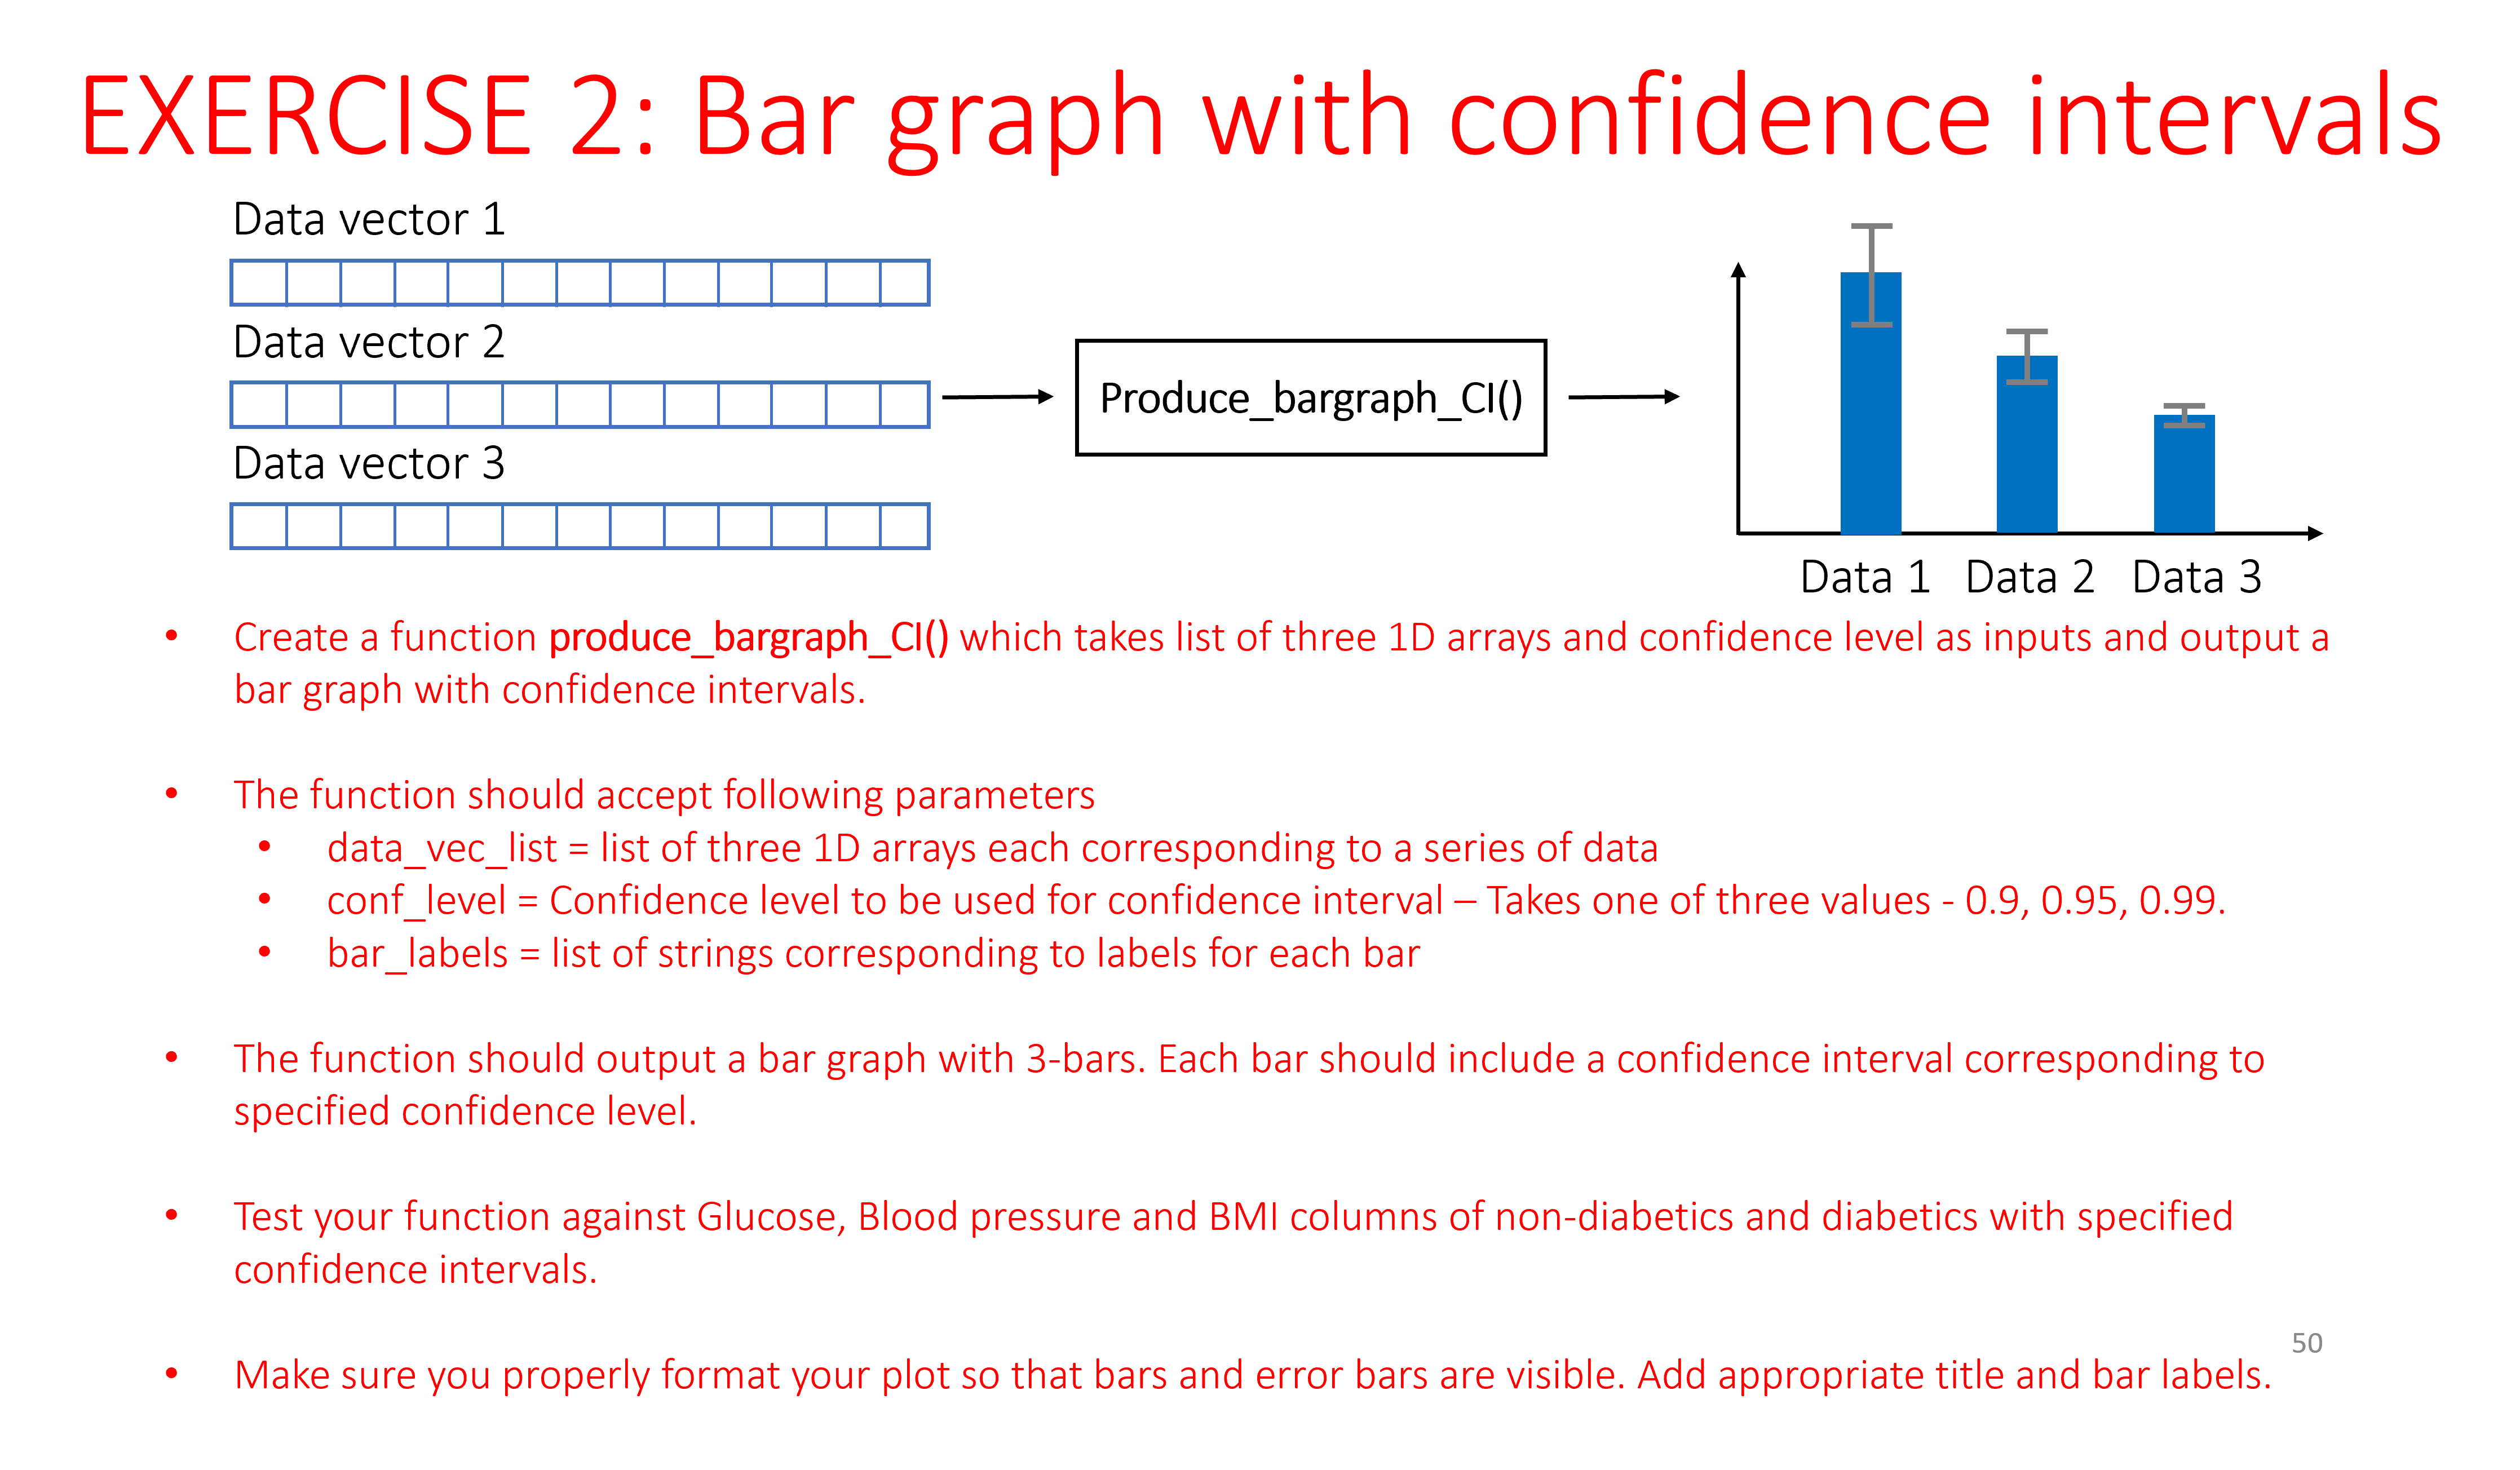

In [9]:
ipyimage('lab4_exercise2.PNG', width = 1000)

In [10]:
# Load diabetes.csv 
# Split the data into diabetic and non-diabetic

diabetes = pd.read_csv('diabetes.csv')
diabetes_np = diabetes.to_numpy()
diabetic_pos_ind = diabetes_np[:, -1] == 1
nondiabetic_neg_ind = diabetes_np[:, -1] == 0
diabetic =  diabetes_np[diabetic_pos_ind, :]
nondiabetic = diabetes_np[nondiabetic_neg_ind, :]

In [11]:
# Extract glucose, blood pressure, and BMI metrics from diabetic and non-diabetic

# non-diabetic metrics
non_diabetic_glucose = nondiabetic[:, 1]
non_diabetic_bp = nondiabetic[:, 2]
non_diabetic_bmi = nondiabetic[:, 5]

# diabetic metrics
diabetic_glucose = diabetic[:, 1]
diabetic_bp = diabetic[:, 2]
diabetic_bmi = diabetic[:, 5]

non_diabetic_list = [non_diabetic_glucose, non_diabetic_bp, non_diabetic_bmi]
diabetic_list = [diabetic_glucose, diabetic_bp, diabetic_bmi]

non_diabetic_bar_labels = ['Non Diabetic Glucose', 'Non Diabetic Bp', 'Non Diabetic Bmi']
diabetic_bar_labels = ['Diabetic Glucose', 'Diabetic Bp', 'Diabetic Bmi']

In [12]:
def produce_bargraph_CI(data_vec_list, conf_level, bar_labels):
    '''
    Produces a bar graph with confidence intervals for the given data vectors.
    Args:
        data_vec_list (list of np.arrays): List containing data vectors for which to compute means and CIs.
        conf_level (float): Confidence level for the intervals (e.g., 0.95 for 95% CI).
        bar_labels (list of str): Labels for each bar in the graph.
    Returns:
        None: Displays a bar graph with confidence intervals.
    '''
    # Determine graph title based on data_vec_list
    if data_vec_list == 'non_diabetic_list':
        title_label = 'Non-Diabetic Individuals'
    else:
        title_label = 'Diabetic Individuals'
    
    # Establishes lists to hold CI lower and upper bounds and error heights
    CI_lower = []
    CI_upper = []
    h = []

    # For loop to calculate CIs and error heights for each data vector in data_vec_list
    for i in range(len(data_vec_list)):

        # Calculate the confidence interval using scipy.stats
        lower, upper = st.t.interval(conf_level, df=len(data_vec_list[i])-1, loc=np.mean(data_vec_list[i]), scale=st.sem(data_vec_list[i]))

        # Append lower and upper bounds to respective lists
        CI_lower.append(lower)
        CI_upper.append(upper)

        # Calculate error height for the bar graph
        error_height = upper - np.mean(data_vec_list[i])

        # Append error height to list h
        h.append(error_height)
    
    # Plotting the bar graph with error bars
    plt.figure(figsize=(10, 6))

    # Create bar graph with error bars by calculating mean values and using h for error heights
    plt.bar(bar_labels, [np.mean(data_vec_list[i]) for i in range(len(data_vec_list))],width= 0.4, yerr=h, error_kw = dict(lw=2, capsize=45, capthick=2))
    plt.xlabel('Metrics', fontsize=14)
    plt.ylabel('Mean Values', fontsize=14)
    
    # Set title based on diabetic or non-diabetic data with confidence level
    plt.title(f'Mean Values for {title_label} with {int(conf_level*100)}% Confidence Intervals', fontsize=16)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.show()

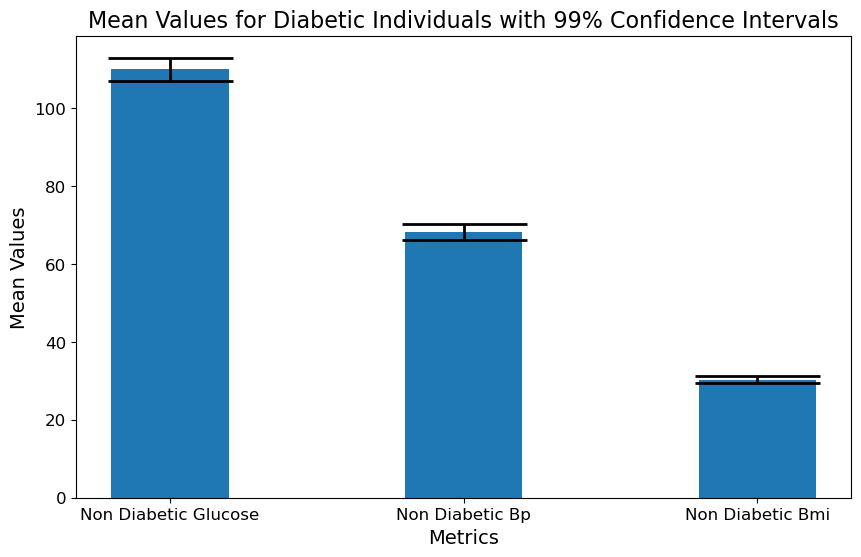

In [13]:
produce_bargraph_CI(data_vec_list = non_diabetic_list, conf_level = 0.99, bar_labels = non_diabetic_bar_labels)

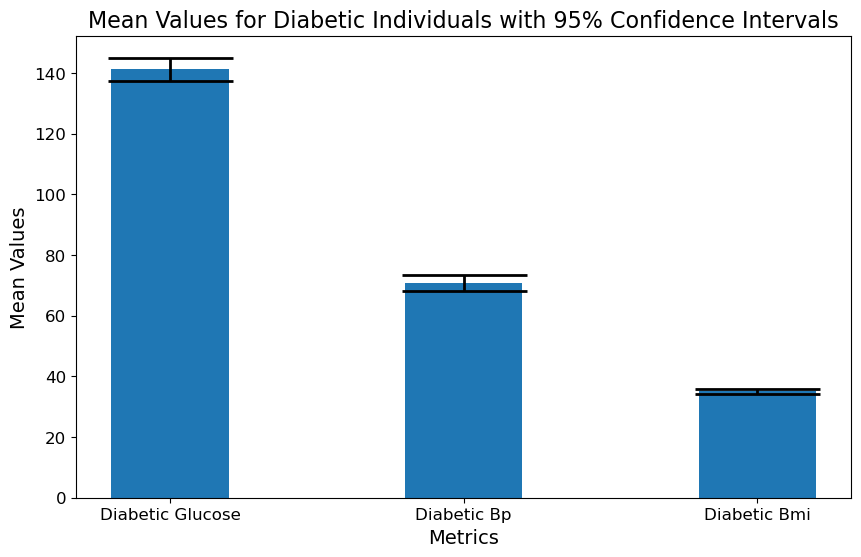

In [14]:
produce_bargraph_CI(data_vec_list = diabetic_list, conf_level = 0.95, bar_labels = diabetic_bar_labels)

### Exercise 3: Rolling Mean/Median Function from Scratch

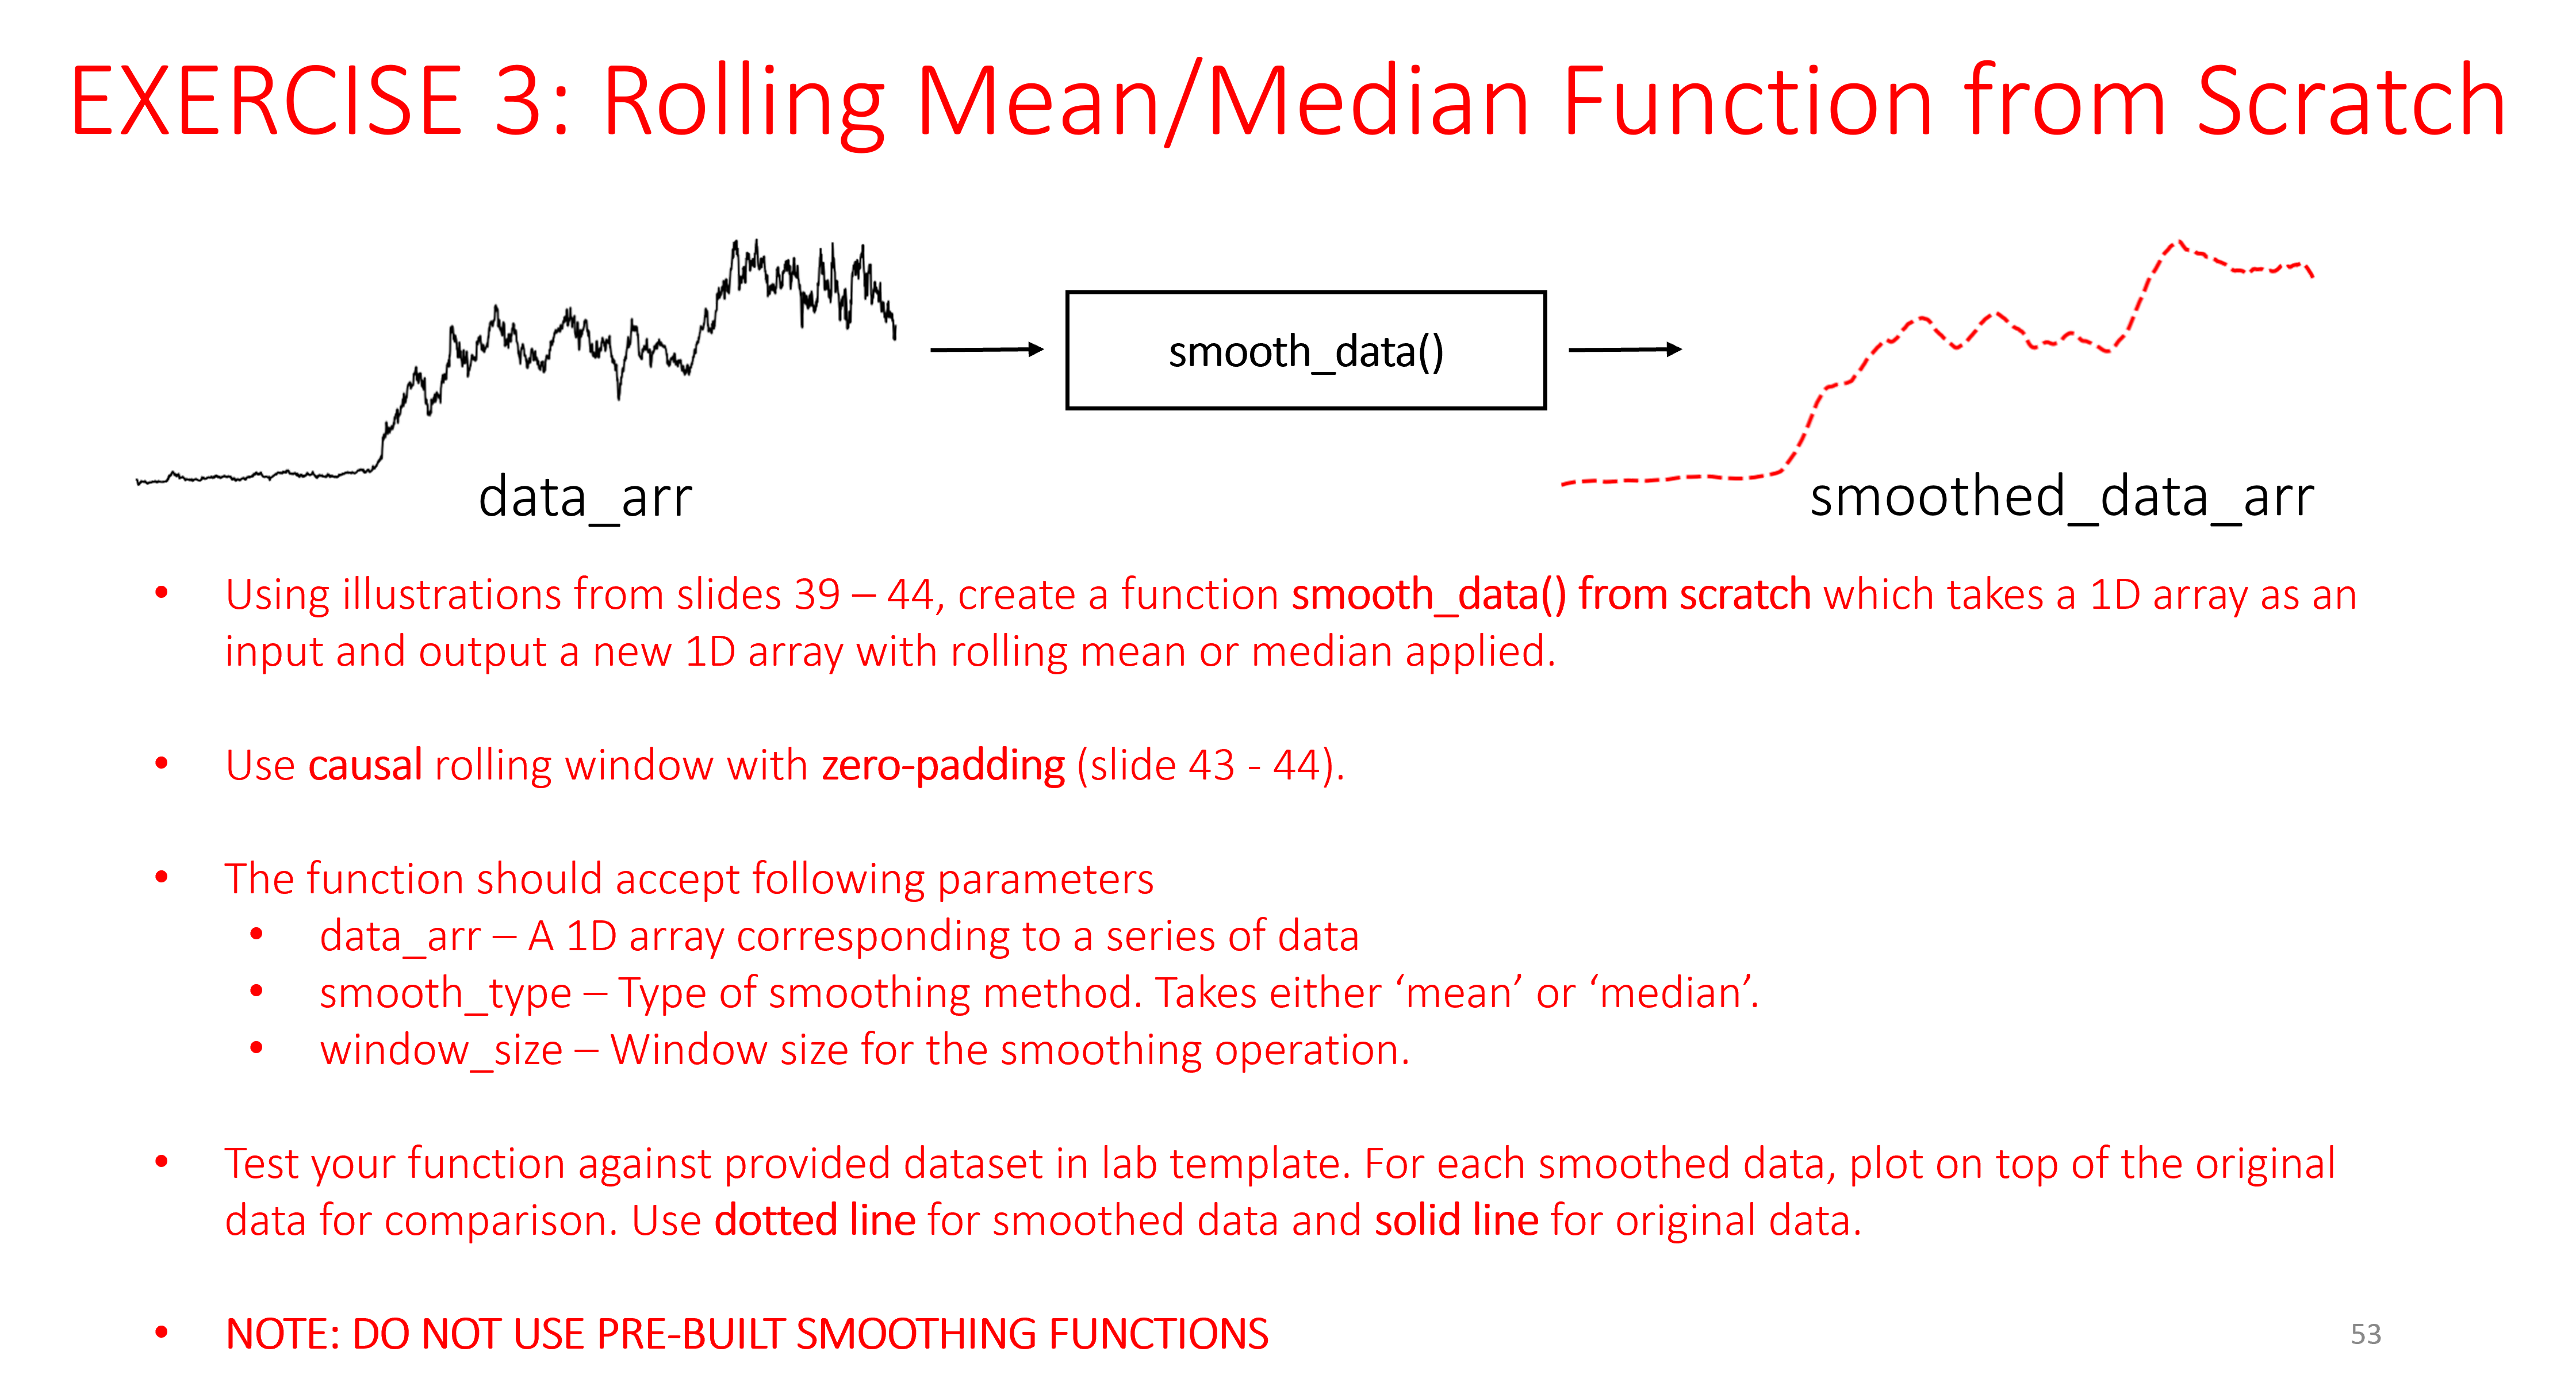

In [15]:
ipyimage('lab4_exercise3.PNG', width = 1000)

In [16]:
# Load stock datasets

tesla = pd.read_csv('TSLA.csv') 
tesla_np = tesla.to_numpy()

google = pd.read_csv('GOOGL.csv') 
google_np = google.to_numpy()

dji = pd.read_csv('DJI.csv') 
dji_np = dji.to_numpy()

In [17]:
# Extract closing price for each stock data

tesla_np_closing = tesla_np[:, 4]
google_np_closing = google_np[:, 4]
DJI_np_closing = dji_np[:, 4]

In [ ]:
def smooth_data(data_arr, smooth_type, window_size):
    '''
    Produces a smoothed data array using either causal rolling mean or rolling median
    Args:
        data_arr (np.array): Data array on which to perform data smoothing
        smooth_type (str): Either 'mean' or 'median'; defines which smoothing type to use
        window_size (int): The size of the rolling window to use for data smoothing
    Returns:
        smoothed_data_arr (np.array): Result of data smoothing process
    '''
    data_arr = np.asarray(data_arr, dtype=np.float64)

    # Creates a zero pad array and adds it to the start of the data array
    zero_pad = np.full(window_size - 1, 0)
    padded_data = np.concatenate((zero_pad, data_arr))

    # Rolling mean smoothing uses cumulative sum to efficiently calculate the mean for each window
    if smooth_type == 'mean':

        # Creates a new array of cumulative sums from the padded data
        cumulative_sum = np.cumsum(padded_data, dtype= float)

        # Calculates the sum of the first window, which is just the window_size - 1
        first_sum = cumulative_sum[window_size - 1]

        # To get all window sums, we subtract the total *before* each window
        # from the total *at the end* of each window

        # Get an array of all "end point" totals (e.g., C[3], C[4], C[5], ...)
        end_totals = cumulative_sum[window_size:]

        # Get an array of all "start point" totals (e.g., C[0], C[1], C[2], ...)
        start_totals = cumulative_sum[:-window_size]

        # Elementwise subtraction gives the sum of each window:
        # [C[3]-C[0], C[4]-C[1], C[5]-C[2], ...]
        other_sums = end_totals - start_totals

        # Combines the first sum with the rest of the sums of each window
        all_sums = np.concatenate(([first_sum], other_sums))

        # Computes the mean of each window by dividing the array of window sums by the window size
        smoothed_data_arr = np.divide(all_sums, window_size)
    
    # Rolling median smoothing converts the 1D array into a 2D view where each row is a window 
    # and takes the median of each window from this new view
    elif smooth_type == 'median':

        # Create a 2D "view" of the 1D data. Each row in this view is a "window"
        # of the original data. More memory efficient, because it doesn't copy the data,
        # it just changes how numpy "looks" at it
        new_view = np.lib.stride_tricks.sliding_window_view(padded_data, window_shape=window_size)

        # Calculate the median of each window (i.e., each row) by specifying axis = 1.
        # This collapses the 2D view back into a 1D array of smoothed values
        smoothed_data_arr = np.median(new_view, axis= 1)
    
    return smoothed_data_arr

In [42]:
# Tesla closing prices, smooth_type = 'mean', window_size = 100
# Your smoothed data should be the same dimension as the original

smoothed_tsla_closing  = smooth_data(tesla_np_closing, smooth_type = 'mean', window_size = 100)

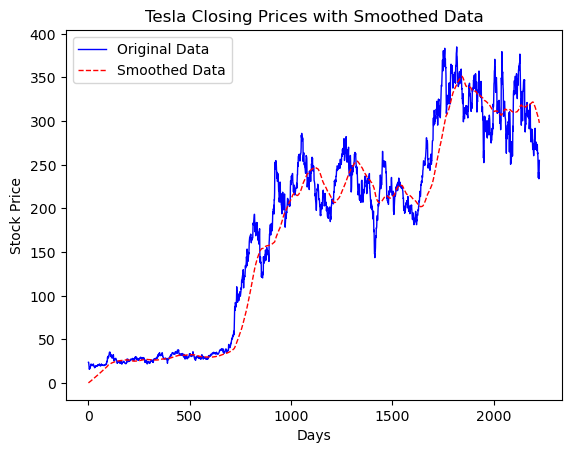

In [43]:
# plot smoothed_tsla_closing on top of tesla_np_closing
plt.plot(tesla_np_closing, linewidth= 1, color= 'blue', ls= '-', label= "Original Data")
plt.plot(smoothed_tsla_closing, linewidth= 1, color= 'red', ls= '--', label= "Smoothed Data",)
plt.title("Tesla Closing Prices with Smoothed Data")
plt.xlabel("Days")
plt.ylabel("Stock Price")
plt.legend()
plt.show()


In [44]:
# Google closing prices, smooth_type = 'median', window_size = 150

smoothed_google_closing  = smooth_data(google_np_closing, smooth_type = 'median', window_size = 150)

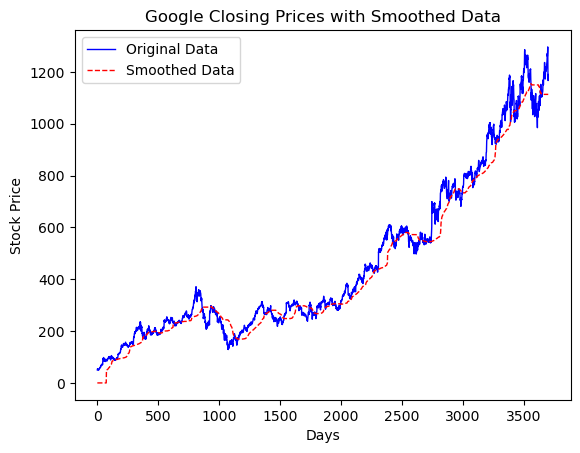

In [45]:
# plot smoothed_google_closing on top of google_np_closing
plt.plot(google_np_closing, linewidth= 1, color= 'blue', ls= '-', label= "Original Data")
plt.plot(smoothed_google_closing, linewidth= 1, color= 'red', ls= '--', label= "Smoothed Data",)
plt.title("Google Closing Prices with Smoothed Data")
plt.xlabel("Days")
plt.ylabel("Stock Price")
plt.legend()
plt.show()



In [46]:
# Dow Jones Index closing prices, smooth_type = 'mean', window_size = 200

smoothed_dji_closing  = smooth_data(DJI_np_closing, smooth_type = 'mean', window_size = 200)

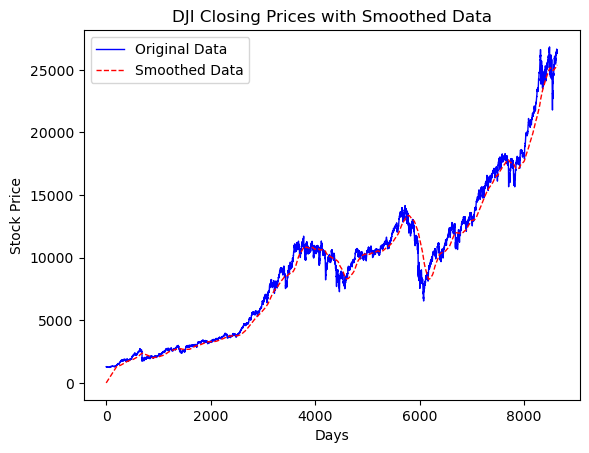

In [47]:
# plot smoothed_dji_closing on top of dji_np_closing
plt.plot(DJI_np_closing, linewidth= 1, color= 'blue', ls= '-', label= "Original Data")
plt.plot(smoothed_dji_closing, linewidth= 1, color= 'red', ls= '--', label= "Smoothed Data",)
plt.title("DJI Closing Prices with Smoothed Data")
plt.xlabel("Days")
plt.ylabel("Stock Price")
plt.legend()
plt.show()


## Extra credit: Code efficiency
### Achieve a runtime speed of < 50ms

In [49]:
timeit -n 1 -r 7 smoothed_google_closing  = smooth_data(google_np_closing, smooth_type = 'median', window_size = 150)

8.52 ms ± 1.82 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


### Exercise 4: Ranking Daily Stock Surges/Crashes

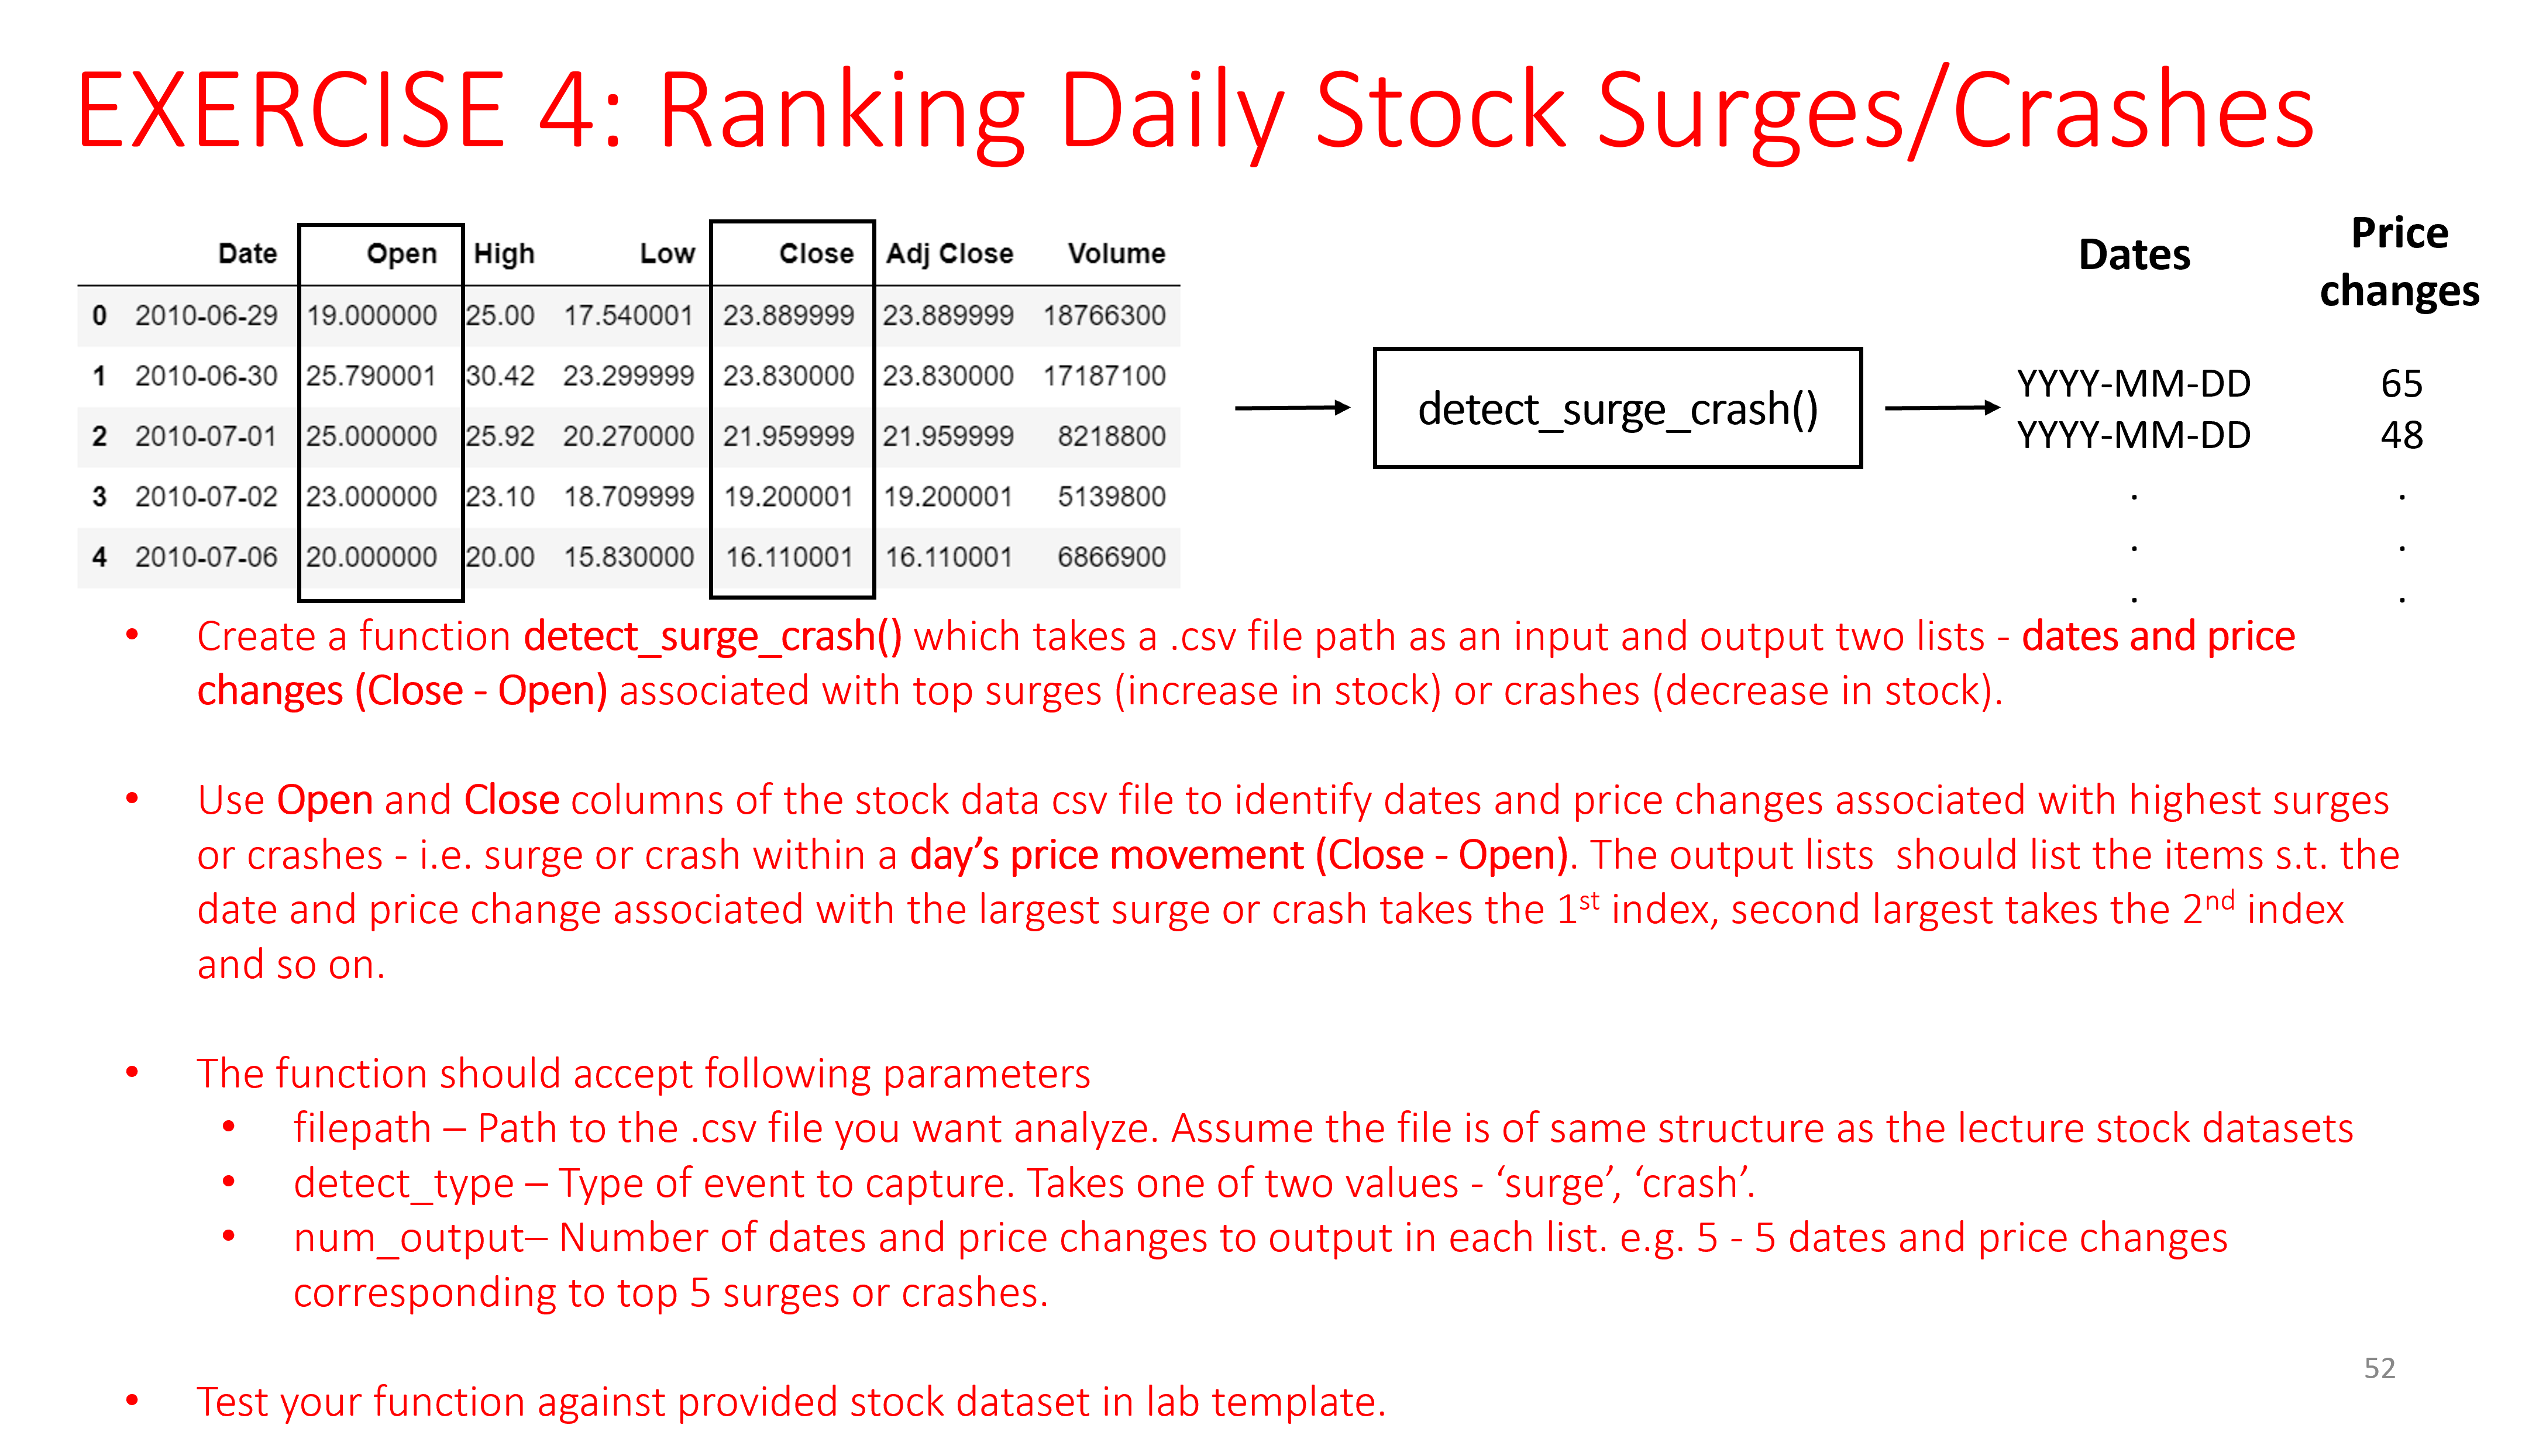

In [26]:
ipyimage('lab4_exercise4.PNG', width = 1000)

In [27]:
def detect_surge_crash(filepath, detect_type, num_output_dates):
    '''
    Takes a .csv file for stock prices and returns two lists: The highest magnitude surges or crashes (defined by the args) in descending order
    Args:
        filepath (str): .csv filepath to open
        detect_type (str): Defines if the function returns highest surges or crashes
        num_output_dates (int): Defines the length of the output lists
    Returns:
        date_list (list): List of dates corresponding to the defined number of highest surges/crashes
        price_change_list (list): List of the defined number of highest surges/crashes
    '''

    # Opens the .csv file as a pandas dataframe then converts it to a numpy array
    pandas_dataframe = pd.read_csv(filepath)
    data = pandas_dataframe.to_numpy()

    # Extracts the dates, opening prices, and closing prices from the numpy array as individual 1D arrays
    dates = data[:, 0]
    price_open = data[:, 1]
    price_close = data[:, 4]

    # Calculates the difference in prices, a positive difference indicating a surge, and a negative difference indicating a crash
    price_diff = price_close - price_open
    
    # Sorts the dates and price differences from lowest to highest differences, 
    # naturally putting the largest crashes at the front of the list and the largest surges at the end of the list
    sorted_indices = np.argsort(price_diff)
    sorted_dates = dates[sorted_indices]
    sorted_diff = price_diff[sorted_indices]
    
    # If detect_type is surge, slices the last values off date and difference lists 
    # and reverses their order, putting them in descending order
    if detect_type == 'surge':
        date_list = sorted_dates[-num_output_dates:].tolist()
        date_list.sort(reverse = True)
        price_change_list = sorted_diff[-num_output_dates:].tolist()
        price_change_list.sort(reverse = True)

    # If detect_type is crash, slices the first values off date and difference lists in ascending order
    elif detect_type == 'crash':
        date_list = sorted_dates[:num_output_dates].tolist()
        price_change_list = np.abs(sorted_diff[:num_output_dates]).tolist()
    
    
    return date_list, price_change_list

In [28]:
date_list_t, price_change_list_t = detect_surge_crash(filepath = 'TSLA.csv', detect_type = 'surge', num_output_dates = 5)

In [29]:
print(date_list_t, price_change_list_t)

['2018-12-26', '2018-10-26', '2018-10-23', '2018-08-07', '2018-04-04'] [35.73001099999999, 34.16000299999999, 30.270019999999988, 26.089995999999985, 22.649993999999992]


In [30]:
date_list_g, price_change_list_g = detect_surge_crash(filepath = 'GOOGL.csv', detect_type = 'crash', num_output_dates = 7)

In [31]:
print(date_list_g, price_change_list_g)

['2018-10-29', '2018-10-24', '2018-03-27', '2018-02-08', '2018-12-04', '2018-10-10', '2018-12-21'] [61.81005899999991, 57.88000499999998, 56.96002199999998, 52.159973000000036, 50.52001900000005, 44.239990000000034, 40.79003899999998]


## Extra credit: Code efficiency
### Achieve a runtime speed of < 10ms

In [32]:
timeit -n 1 -r 7 date_list_t, price_change_list_t = detect_surge_crash(filepath = 'TSLA.csv', detect_type = 'surge', num_output_dates = 5)

10.5 ms ± 4.22 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


### Exercise 5: Human Debugger

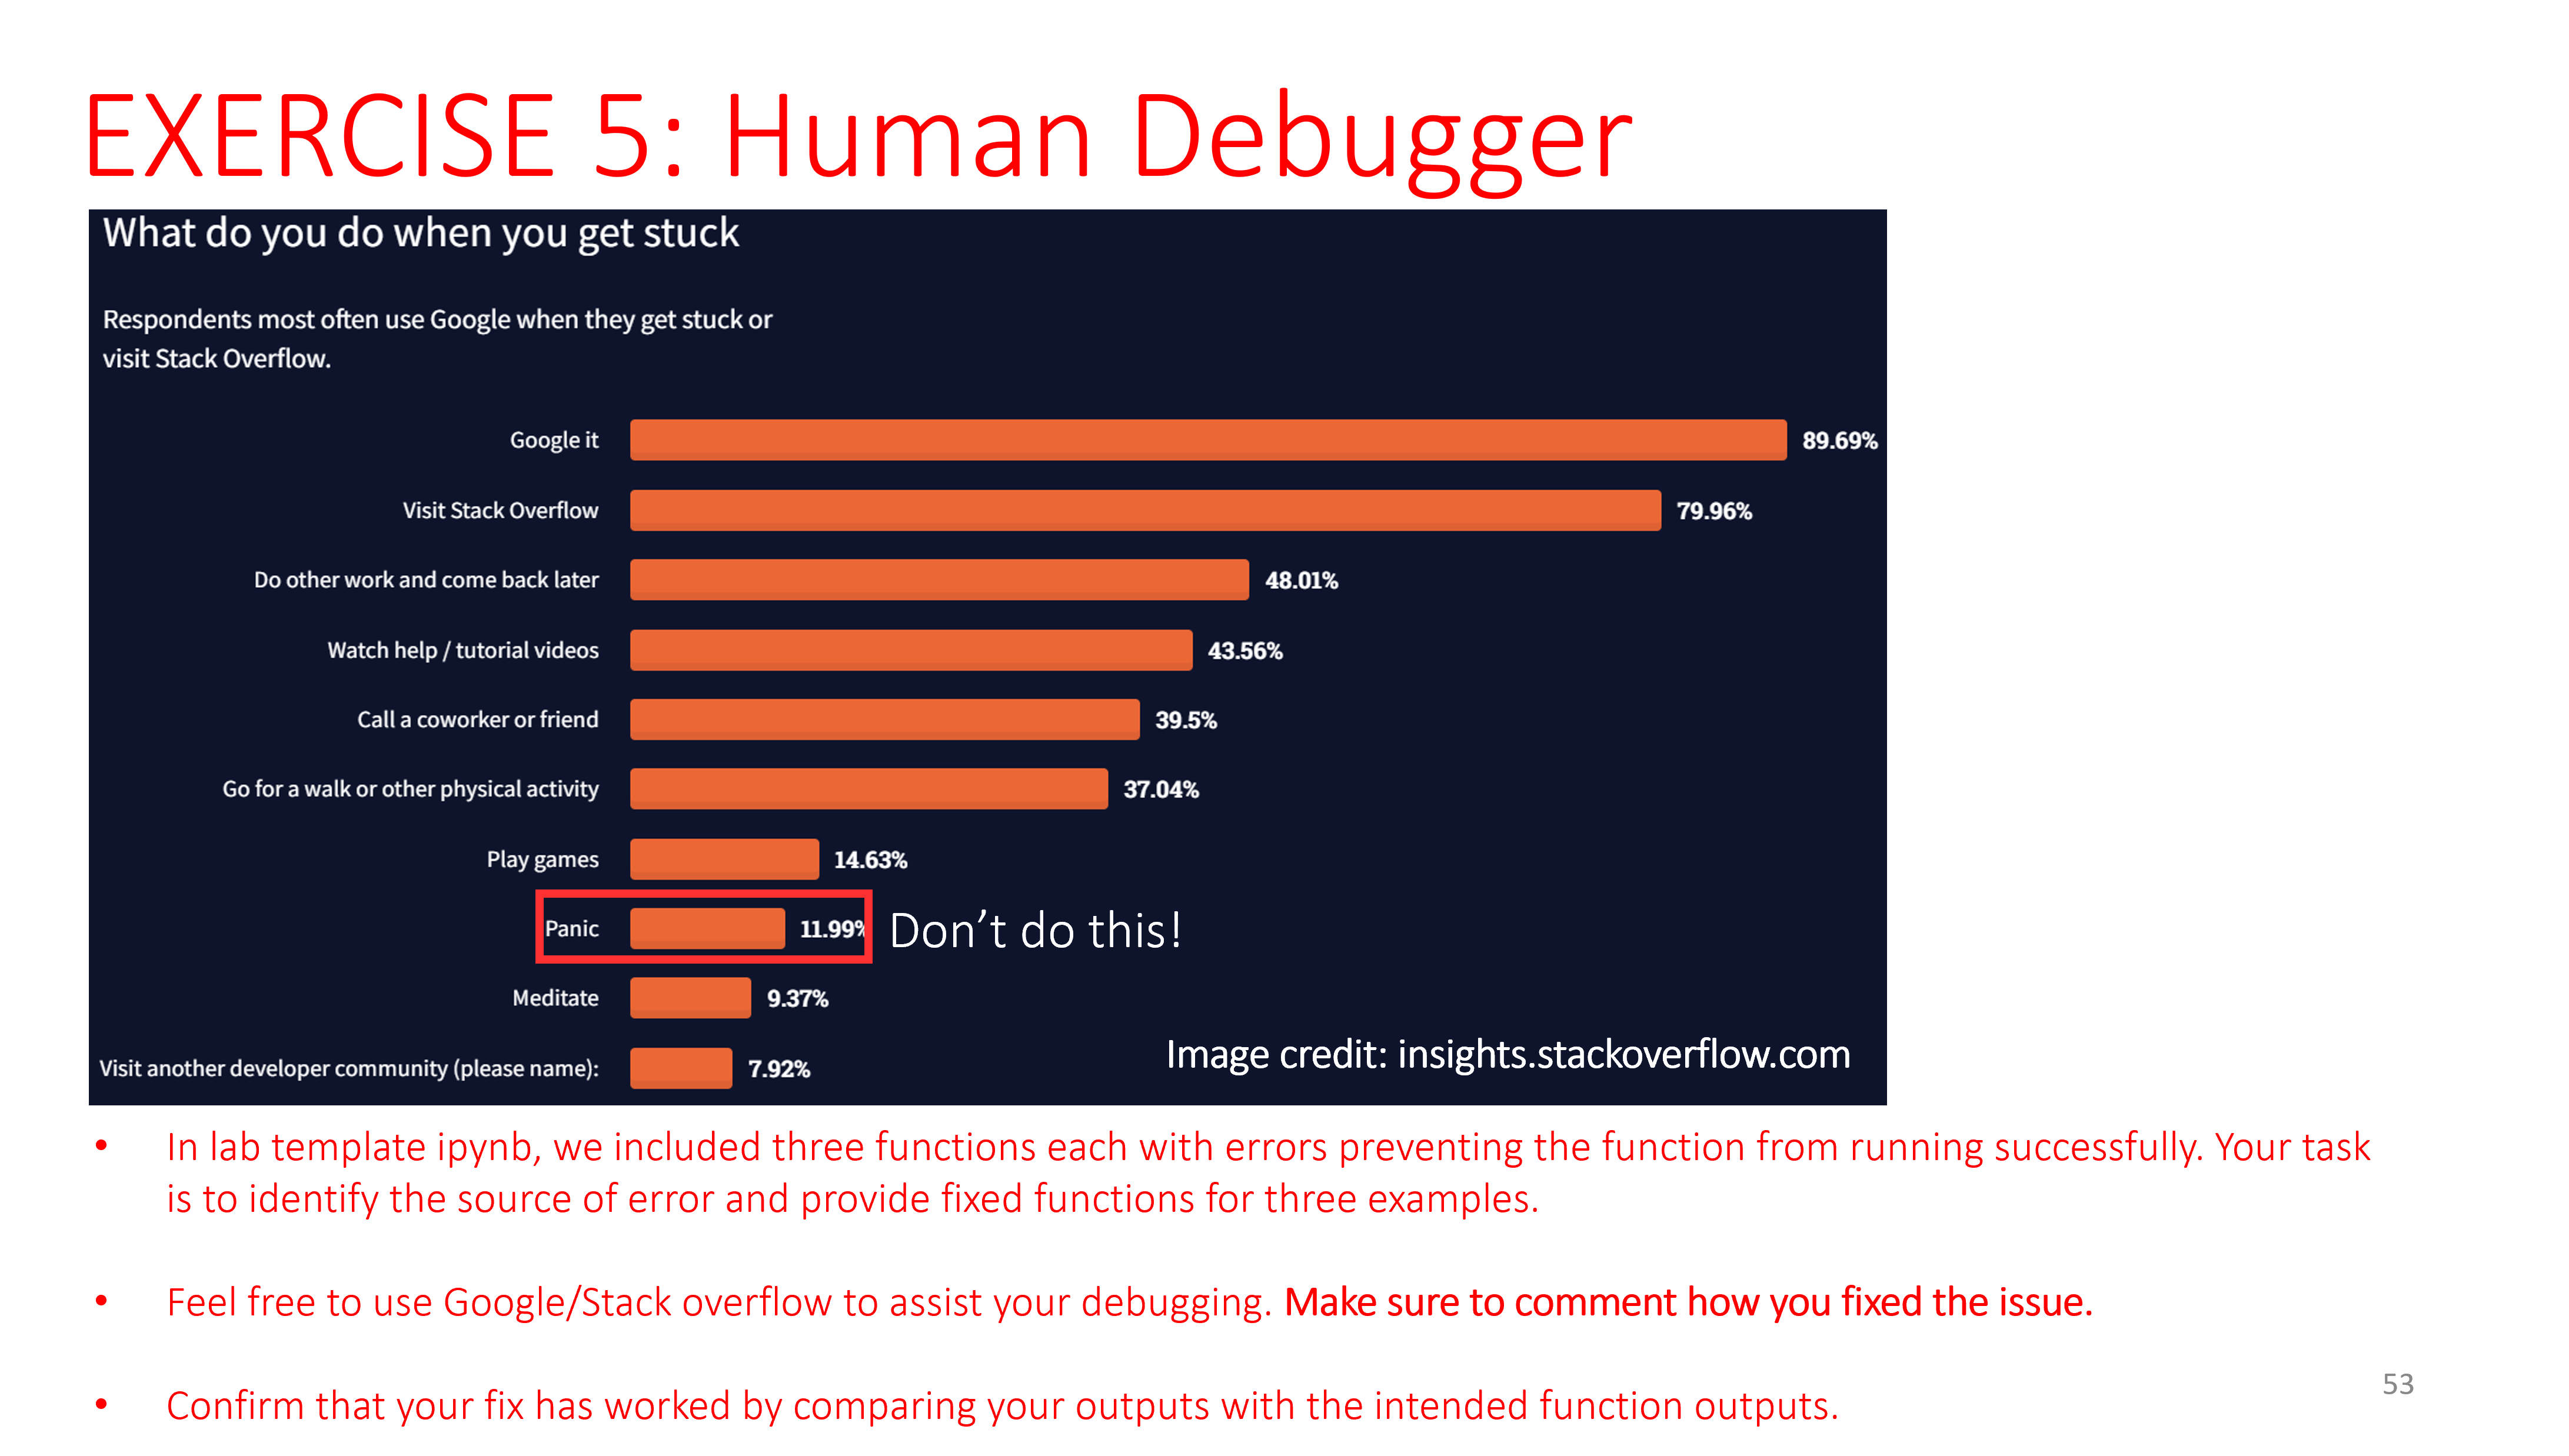

In [33]:
ipyimage('lab4_exercise5.PNG', width = 1000)

### Faulty function #1 

In [34]:
def average_data_per_col(arr_2d):
    
    # NOTE FROM YOUR FRIEND PREPARING FOR STARBUCKS SOFTWARE ENGINEER TECH INTERVIEW 
    """  The function takes numpy 2d array as an input, computes mean for each column data, and outputs 1D array 
         with the length equal to the # of columns.
         
         For some reason I keep getting errors.... I need your help to debug the code.
         I need this position so I can get free ice lattes... :(
    
    """
    
    # placeholder for averaged values
    averaged_data = ()
    
    # Loop through each column data to compute mean and append to averaged_data 
    for k in range(len(arr_2d[:, 0])):
        
        averaged_column_data = np.mean(arr_2d[:, k])
        averaged_data.append(averaged_column_data)
        
    # Return numpy array form of the averaged_data
    return np.array(averaged_data)

In [35]:
# Load diabetes.csv and convert to numpy array

diabetes = pd.read_csv('diabetes.csv')
diabetes_np = diabetes.to_numpy()

In [36]:
# Run faulty function 1

averaged_diabetic_attributes =  average_data_per_col(diabetes_np)

AttributeError: 'tuple' object has no attribute 'append'

In [ ]:
# YOUR FIXED FUNCTION HERE
# Make sure you comment on your fixes

def average_data_per_col_fixed(arr_2d):
    '''
    Fixed function for averaging column values
    '''
    
    # Original function defined averaged_data as a tuple, which cannot be modified with append()
    # I achieved the desired result by using np.mean along the column axis 0 to compute the mean of each column 

    averaged_column_data = np.mean(arr_2d, axis=0)
      
    return averaged_column_data

In [ ]:
# Test your fixed function

averaged_diabetic_attributes =  average_data_per_col_fixed(diabetes_np)

In [ ]:
# Compare with correct results

correct_result_func1 = np.load('E5_correct_output_1.npy')

# Should return True if the result is correct
np.sum(np.round(correct_result_func1, 3) == np.round(averaged_diabetic_attributes, 3)) == len(correct_result_func1) 

### Faulty function #2

In [ ]:
def daily_stock_change_2_normalized_percentage(opening_price_arr, closing_price_arr):
    
    # NOTE FROM YOUR FRIEND WHO INVESTED IN TESLA
    """  I want to write a function which takes 2 1D numpy arrays of each corresponding to opening/closing prices of stock
         and output 1D array of daily stock change in percentages. 
         
         I want the percentages scale to be in a scale such that 1 = 100%, -0.5 = -50%, 1.5 = 150%  etc.
         For example, day 1 opening: $10, day 1 closing: $15, change in scaled percecntage: 0.5.
         
         I am not really getting errors but the numbers don't look right... Can you help me?? :'( 
    
    """
    
    # placeholder for change percentage values
    change_percentages = np.zeros(len(opening_price_arr), dtype = 'int')
    
    # Loop through each opening/closing price to compute the change percentage
    for date_num in range(len(opening_price_arr)):
        
        change_percentages[date_num] = opening_price_arr[date_num] - closing_price_arr[date_num] / opening_price_arr[date_num]
    
    return change_percentages

In [ ]:
# Load tsla.csv and convert to numpy array

tesla = pd.read_csv('TSLA.csv') 
tesla_np = tesla.to_numpy()

In [ ]:
# Run faulty function 2

change_percentages = daily_stock_change_2_normalized_percentage(tesla_np[:, 1], tesla_np[:, 4])
print(change_percentages)

[ 17  24  24 ... 237 244 242]


In [ ]:
# YOUR FIXED FUNCTION HERE
# Make sure you comment on your fixes

def daily_stock_change_2_normalized_percentage_fixed(opening_price_arr, closing_price_arr):
    '''
    Fixed function for percentage changes
    '''

    # Condensed to one line
    # The math operation being performed on the first function was incorrect
    # Updated with correct expression (Close - open) / open = percent difference
    # No point in using a for loop because numpy can use vectorized operations much faster
    output = (closing_price_arr - opening_price_arr) / opening_price_arr
    
    return output

In [ ]:
# Test your fixed function

change_percentages = daily_stock_change_2_normalized_percentage_fixed(tesla_np[:, 1], tesla_np[:, 4])
print(change_percentages)

[0.2573683684210526 -0.07599848483914375 -0.12160004 ...
 -0.020263809413511188 -0.005783634640214459 0.045804961675531164]


In [ ]:
# Compare with correct results

correct_result_func2 = np.load('E5_correct_output_2.npy')


# Should return True if the result is correct
np.sum(np.round(correct_result_func2.astype(float), 3) == np.round(change_percentages.astype(float), 3)) == len(correct_result_func2) 

np.True_

### Faulty function #3

In [ ]:
def subset_diabetes_by_age(diabetes_data):
    
    # NOTE FROM YOUR FRIEND WHO WORKS AT UW IHME`
    """ The function takes diabetes pandas data frame as an input and outputs a subplot of 3 x 1 with three histograms.    
    
        Specifically, I want to divide the diabetes data into three age groups - 
            1. 20 to 40
            2. 40 to 60
            3. 60 to 80
            
        and plot 3 histograms of glucose distribution (50 bins per histogram) in 3 x 1 python subplots.
        
        I seem to be getting error from very beginning even before I divide the dataset....
        My coworkers at IHME prefer R rather than Python... so you are my only hope!  
    
    """
    
    # Extract the age column of the diabetes_data 
    age_column = diabetes_data[:, 8] 
    
    # Construct boolean mask for each age group 
    age_20_40_bool_mask = age_column > 20 + age_column < 40
    age_40_60_bool_mask = age_column > 40 + age_column < 60
    age_60_80_bool_mask = age_column > 60 + age_column < 80
    
    # Get glucose data for each age group via applying the boolean mask for each age group
    age_20_40_glucose = diabetes_data[age_20_40_bool_mask, 2]
    age_40_60_glucose = diabetes_data[age_40_60_bool_mask, 2]
    age_60_80_glucose = diabetes_data[age_60_80_bool_mask, 2]
    
    # Plot the histogram for each age group in 3 x 1 subplot
    fig = plt.figure(figsize=(15,7))
    
    plt.subplot(3,1,1)
    
    plt.hist(age_20_40_glucose, bins = 50)
    plt.title('Age 20 to 40', fontsize = 15)
    
    plt.subplot(3,1,2)
    
    plt.hist(age_40_60_glucose, bins = 50)
    plt.title('Age 40 to 60', fontsize = 15)
    
    plt.subplot(3,1,3)
    
    plt.hist(age_60_80_glucose, bins = 50)
    plt.title('Age 60 to 80', fontsize = 15)
    
    plt.tight_layout()
    
    plt.show()

In [ ]:
# Load diabetes.csv as pandas dataframe

diabetes = pd.read_csv('diabetes.csv')

In [ ]:
# Run faulty function 3

subset_diabetes_by_age(diabetes_data = diabetes)

InvalidIndexError: (slice(None, None, None), 8)

In [ ]:
# YOUR FIXED FUNCTION HERE
# Make sure you comment on your fixes

def subset_diabetes_by_age_fixed(diabetes_data):
    ''' 
    Corrected Function
    '''

    # Converted diabetes_data dataframe to numpy
    diabetes_data_np = diabetes_data.to_numpy()

    ## Fixed the indexing. Original function is selecting "Outcome" instead of "Age"
    # Extract the age column of the diabetes_data 
    age_column = diabetes_data_np[:, 7] 
    
    ## Fixed boolean mask generation. Added parentheses and & operater to generate correct boolean masks
    # Construct boolean mask for each age group 
    age_20_40_bool_mask = (age_column >= 20) & (age_column <= 40)
    age_40_60_bool_mask = (age_column > 40) & (age_column <= 60)
    age_60_80_bool_mask = (age_column > 60) & (age_column <= 80)
    
    ## Fixed the indexing. Original function is selecting "blood pressure" instead of "glucose"
    # Get glucose data for each age group via applying the boolean mask for each age group
    age_20_40_glucose = diabetes_data_np[age_20_40_bool_mask, 1]
    age_40_60_glucose = diabetes_data_np[age_40_60_bool_mask, 1]
    age_60_80_glucose = diabetes_data_np[age_60_80_bool_mask, 1]
    
    # Plot the histogram for each age group in 3 x 1 subplot
    fig = plt.figure(figsize=(15,7))
    
    plt.subplot(3,1,1)
    
    plt.hist(age_20_40_glucose, bins = 50)
    plt.title('Age 20 to 40', fontsize = 15)
    
    plt.subplot(3,1,2)
    
    plt.hist(age_40_60_glucose, bins = 50)
    plt.title('Age 40 to 60', fontsize = 15)
    
    plt.subplot(3,1,3)
    
    plt.hist(age_60_80_glucose, bins = 50)
    plt.title('Age 60 to 80', fontsize = 15)
    
    plt.tight_layout()
    
    plt.show()
    
    

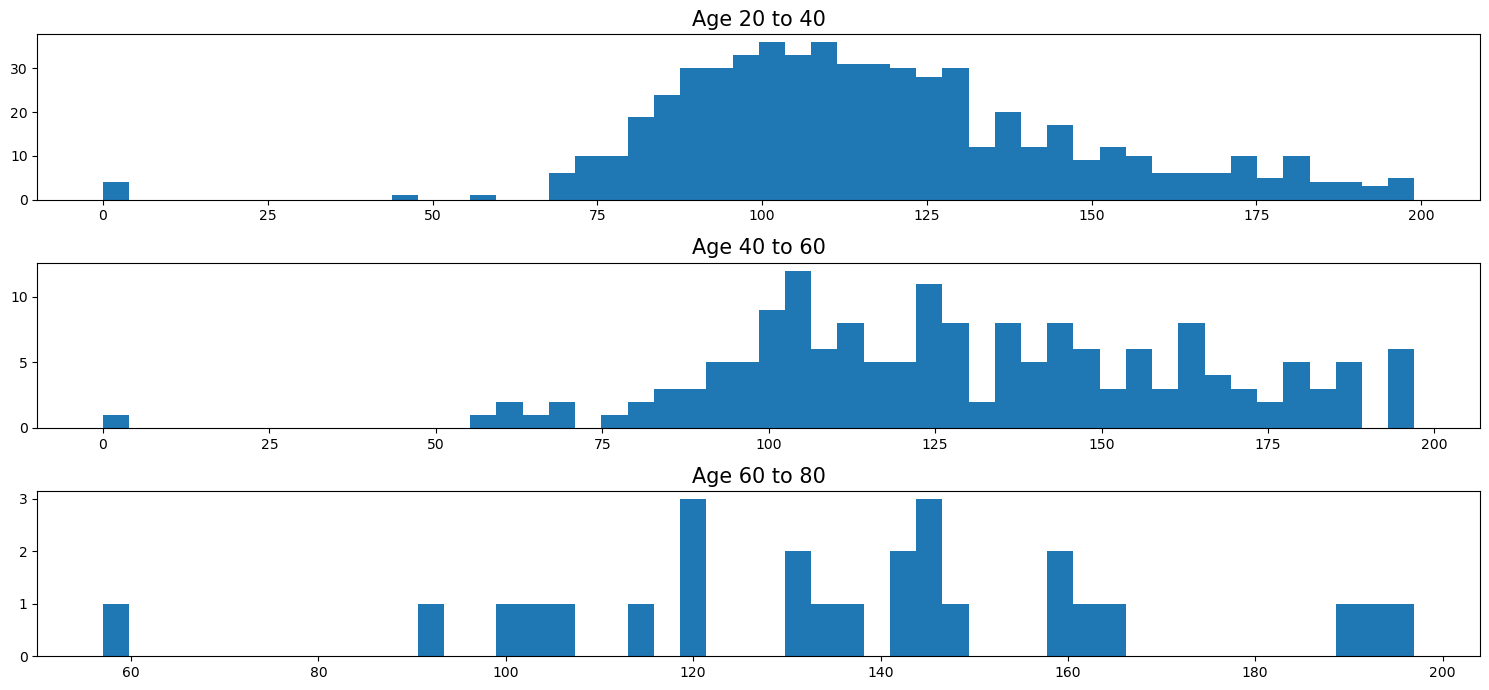

In [ ]:
# Test your fixed function
# Compare your plot with the correct plot provided in template folder

subset_diabetes_by_age_fixed(diabetes_data = diabetes)